# Figure 4 — Shade, Buildings and Phenology

**Claim**: the tree contribution must be isolated from the building baseline; phenology
changes the seasonal balance.

Panels: A) four-state decomposition (Palma), B) marginal tree benefit given buildings,
by mode (walk/bike; car BLOCKED), C) evergreen vs deciduous annual cycle (v1, tree-only,
modelled phenology -- not observational validation), D) building-coefficient sensitivity
(Palma only -- cross-city PARTIAL pending Phase 2).


In [1]:

import sys, json
from pathlib import Path
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "configs").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT / "notebooks" / "paper_figures"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from plotting_utils import (set_nature_style, new_panel_fig, label_panel, save_panel,
                              save_source_table, blocked_panel, make_composite, MODE_COLORS, SEED)
np.random.seed(SEED); set_nature_style()
FIG_DIR = REPO_ROOT / "figures/paper/main/figure4"; TAB_DIR = REPO_ROOT / "reports/paper_figures/figure4"
FIG_DIR.mkdir(parents=True, exist_ok=True); TAB_DIR.mkdir(parents=True, exist_ok=True)


## Audit

In [2]:

four_state_path = REPO_ROOT / "reports/thermal/dose_benefit_analysis/tables/palma_pilot_four_state_decomposition.csv"
sensitivity_path = REPO_ROOT / "reports/thermal/dose_benefit_analysis/tables/palma_building_coefficient_sensitivity.csv"
v1_path = REPO_ROOT / "data/thermal/dose_benefit_2022.parquet"
building_shadow_dir = REPO_ROOT / "data/palma_de_mallorca/green_mobility/thermal/building_shadow"
canopy_v2_path = REPO_ROOT / "data/palma_de_mallorca/green_mobility/thermal/canopy_fraction_v2.parquet"
walk_bike_path = REPO_ROOT / "data/palma_de_mallorca/green_mobility/exposure/weekday_full_walk_bike_edge_bins.parquet"

print("four-state decomposition (Palma):", four_state_path.exists())
print("building coefficient sensitivity (Palma):", sensitivity_path.exists())
print("v1 dose-benefit (26 dates, tree-only):", v1_path.exists())
print("building_shadow + canopy_v2 + walk_bike (for mode-split recompute):",
      building_shadow_dir.exists(), canopy_v2_path.exists(), walk_bike_path.exists())
print("\nOther cities (Bilbao/Sevilla) four-state/sensitivity: PARTIAL/BLOCKED -- Phase 2 in progress, not complete at notebook build time")


four-state decomposition (Palma): True
building coefficient sensitivity (Palma): True
v1 dose-benefit (26 dates, tree-only): True
building_shadow + canopy_v2 + walk_bike (for mode-split recompute): True True True

Other cities (Bilbao/Sevilla) four-state/sensitivity: PARTIAL/BLOCKED -- Phase 2 in progress, not complete at notebook build time


## Panel A — Four-state decomposition (Palma, walk+bike combined; car BLOCKED)

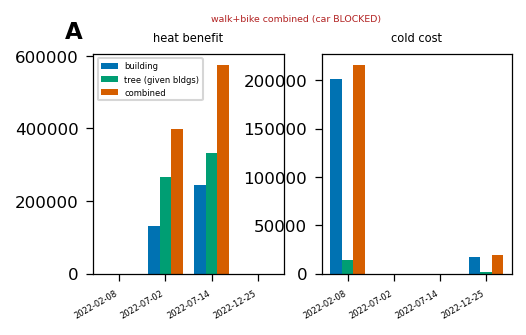

In [3]:

panel_a_ready = four_state_path.exists()
if panel_a_ready:
    decomp = pd.read_csv(four_state_path)
    ev = decomp[decomp["phenology"]=="evergreen"].set_index("date")
    dates = ["2022-02-08","2022-07-02","2022-07-14","2022-12-25"]
    ev = ev.loc[[d for d in dates if d in ev.index]]
    save_source_table(decomp, TAB_DIR, "panel_a")

    fig, axes = plt.subplots(1, 2, figsize=(3.6, 1.9))
    x = range(len(ev))
    w = 0.25
    for ax, colb, colt, colbt, title in [
        (axes[0], "building_heat_benefit", "tree_heat_benefit_given_buildings", "combined_heat_benefit", "heat benefit"),
        (axes[1], "building_cold_cost", "tree_cold_cost_given_buildings", "combined_cold_cost", "cold cost")]:
        ax.bar([i-w for i in x], ev[colb], w, label="building", color="#0072B2")
        ax.bar([i for i in x], ev[colt], w, label="tree (given bldgs)", color="#009E73")
        ax.bar([i+w for i in x], ev[colbt], w, label="combined", color="#D55E00")
        ax.set_xticks(list(x)); ax.set_xticklabels(ev.index, rotation=30, ha="right", fontsize=4)
        ax.set_title(title, fontsize=5.5)
        ax.axhline(0, color="black", lw=0.4)
    axes[0].legend(fontsize=4, loc="upper left")
    label_panel(axes[0], "A")
    fig.suptitle("walk+bike combined (car BLOCKED)", fontsize=4.5, color="firebrick", y=1.02)
    save_panel(fig, FIG_DIR, "panel_a")
    plt.show()
else:
    fig, ax = new_panel_fig(3.5, 2.6)
    blocked_panel(ax, "A", "four-state decomposition not found", [str(four_state_path)])
    save_panel(fig, FIG_DIR, "panel_a")
    plt.show()


## Panel B — Marginal tree benefit given buildings, by mode (walk vs bike separately; car BLOCKED)

Light re-aggregation of already-computed building_shadow + canopy_v2 + raw walk/bike edge-bins, splitting person-hours by mode before the dose sum (no ray-casting/canopy recomputation).

   mode        date  tree_heat_benefit_given_buildings  building_heat_benefit  \
0  walk  2022-07-14                      307820.029173          230753.973150   
1  bike  2022-07-14                       23378.611121           13994.628309   

    person_hours  
0  732059.912008  
1   44491.221175  


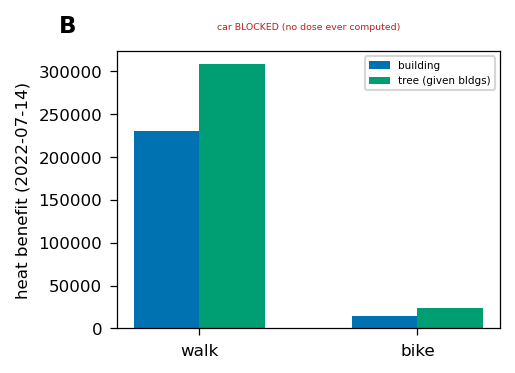

In [4]:

panel_b_ready = building_shadow_dir.exists() and canopy_v2_path.exists() and walk_bike_path.exists()
if panel_b_ready:
    from green_mobility.thermal.canopy_phenology import canopy_shade_multiplier
    from green_mobility.thermal.era5_utci import load_ambient_utci, daylight_fraction_by_hour
    from green_mobility.thermal.dose_benefit import heat_dose, cold_dose
    from green_mobility.thermal.shade_states import four_state_reductions, STATES
    import datetime as dt

    utci_path = REPO_ROOT / "data/climate_raw/era5/utci_palma_de_mallorca_2022.nc"
    LAT, LON = 39.5696, 2.6502
    canopy = pd.read_parquet(canopy_v2_path)
    canopy15 = canopy[canopy["buffer_m"]==15.0][["edge_id","fused_canopy_fraction"]].set_index("edge_id")
    bins = pd.read_parquet(walk_bike_path)
    bins = bins[bins["mode"].isin(["walk","bike"])].copy()
    bins["hour"] = (bins["bin_start_s"]//3600).astype(int) % 24

    rows = []
    d = dt.date(2022,7,14)
    building = pd.read_parquet(building_shadow_dir / "date=2022-07-14/edge_hour_building_shadow.parquet")[["edge_id","hour","building_shadow_fraction"]]
    ambient = load_ambient_utci(utci_path, LAT, LON, on_date=d)
    daylight = daylight_fraction_by_hour(LAT, LON, d)
    weather = ambient.merge(daylight, on="hour")
    mult = canopy_shade_multiplier(d, "evergreen")
    base = canopy15.reset_index(); base["tree_shadow_fraction"] = base["fused_canopy_fraction"]*mult
    merged = building.merge(base[["edge_id","tree_shadow_fraction"]], on="edge_id", how="inner").merge(weather, on="hour", how="left")
    merged["tree_effective_frac"] = merged["tree_shadow_fraction"]*merged["daylight_fraction"]

    for mode in ("walk","bike"):
        ph = bins[bins["mode"]==mode].groupby(["edge_id","hour"])["person_seconds"].sum().reset_index()
        ph["n"] = ph["person_seconds"]/3600.0
        m2 = merged.merge(ph[["edge_id","hour","n"]], on=["edge_id","hour"], how="inner")
        reductions = four_state_reductions(m2["tree_effective_frac"], m2["building_shadow_fraction"], tree_coef=6.0, building_coef=6.0)
        doses = {}
        for s in STATES:
            u = m2["utci_ambient_c"] - reductions[s]
            doses[s] = {"heat": heat_dose(pd.DataFrame({"utci_c":u,"n":m2["n"]}), utci_col="utci_c", n_col="n"),
                        "cold": cold_dose(pd.DataFrame({"utci_c":u,"n":m2["n"]}), utci_col="utci_c", n_col="n")}
        rows.append({"mode": mode, "date": "2022-07-14",
                     "tree_heat_benefit_given_buildings": doses["B"]["heat"]-doses["BT"]["heat"],
                     "building_heat_benefit": doses["0"]["heat"]-doses["B"]["heat"],
                     "person_hours": m2["n"].sum()})
    panel_b_df = pd.DataFrame(rows)
    save_source_table(panel_b_df, TAB_DIR, "panel_b")
    print(panel_b_df)

    fig, ax = new_panel_fig(3.3, 2.4)
    x = np.arange(len(panel_b_df))
    ax.bar(x-0.15, panel_b_df["building_heat_benefit"], 0.3, label="building", color="#0072B2")
    ax.bar(x+0.15, panel_b_df["tree_heat_benefit_given_buildings"], 0.3, label="tree (given bldgs)", color="#009E73")
    ax.set_xticks(x); ax.set_xticklabels(panel_b_df["mode"])
    ax.set_ylabel("heat benefit (2022-07-14)"); ax.legend(fontsize=5)
    ax.text(0.5, 1.08, "car BLOCKED (no dose ever computed)", transform=ax.transAxes, ha="center", fontsize=4.5, color="firebrick")
    label_panel(ax, "B")
    save_panel(fig, FIG_DIR, "panel_b")
    plt.show()
else:
    fig, ax = new_panel_fig(3.3, 2.4)
    blocked_panel(ax, "B", "inputs for mode-split recomputation not found",
                  [str(building_shadow_dir), str(canopy_v2_path), str(walk_bike_path)])
    save_panel(fig, FIG_DIR, "panel_b")
    plt.show()


## Panel C — Evergreen vs deciduous annual cycle (v1, walk+bike combined, tree-only)

The deciduous leaf-cover ramp is a PRESCRIBED model input (round-number placeholder day-of-year, not validated per species/city) -- shown as a MODELLED result, not observational validation.

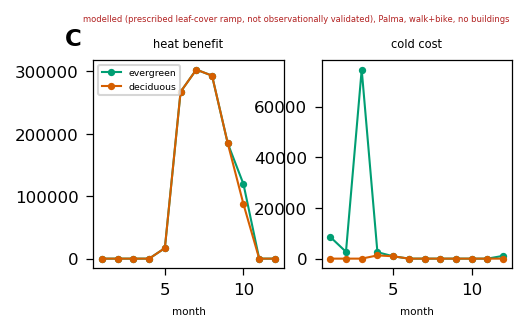

In [5]:

panel_c_ready = v1_path.exists()
if panel_c_ready:
    v1 = pd.read_parquet(v1_path)
    monthly_medoids = ["2022-01-15","2022-02-09","2022-03-07","2022-04-10","2022-05-12","2022-06-06",
                        "2022-07-20","2022-08-06","2022-09-23","2022-10-28","2022-11-14","2022-12-25"]
    days_in_month = {1:31,2:28,3:31,4:30,5:31,6:30,7:31,8:31,9:30,10:31,11:30,12:31}
    v1m = v1[(v1["city"]=="palma_de_mallorca") & (v1["date"].isin(monthly_medoids))].copy()
    v1m["month"] = pd.to_datetime(v1m["date"]).dt.month
    v1m["weight"] = v1m["month"].map(days_in_month)
    agg = v1m.groupby(["month","canopy_type"]).apply(
        lambda g: pd.Series({"heat_benefit": (g["heat_benefit"]*g["weight"]).sum()/g["weight"].sum(),
                              "cold_cost": (g["cold_cost"]*g["weight"]).sum()/g["weight"].sum()}),
        include_groups=False).reset_index()
    save_source_table(agg, TAB_DIR, "panel_c")

    fig, axes = plt.subplots(1, 2, figsize=(3.6, 1.8))
    for ax, col, title in [(axes[0], "heat_benefit", "heat benefit"), (axes[1], "cold_cost", "cold cost")]:
        for ctype, color in [("evergreen","#009E73"), ("deciduous","#D55E00")]:
            sub = agg[agg["canopy_type"]==ctype].sort_values("month")
            ax.plot(sub["month"], sub[col], "-o", color=color, label=ctype, ms=2.5, lw=1)
        ax.set_title(title, fontsize=5.5); ax.set_xlabel("month", fontsize=5)
    axes[0].legend(fontsize=4.5)
    label_panel(axes[0], "C")
    fig.suptitle("modelled (prescribed leaf-cover ramp, not observationally validated), Palma, walk+bike, no buildings",
                 fontsize=4, y=1.05, color="firebrick")
    save_panel(fig, FIG_DIR, "panel_c")
    plt.show()
else:
    fig, ax = new_panel_fig(3.5, 2.6)
    blocked_panel(ax, "C", "v1 dose-benefit not found", [str(v1_path)])
    save_panel(fig, FIG_DIR, "panel_c")
    plt.show()


## Panel D — Building-coefficient sensitivity (Palma only; cross-city PARTIAL, Phase 2 pending)

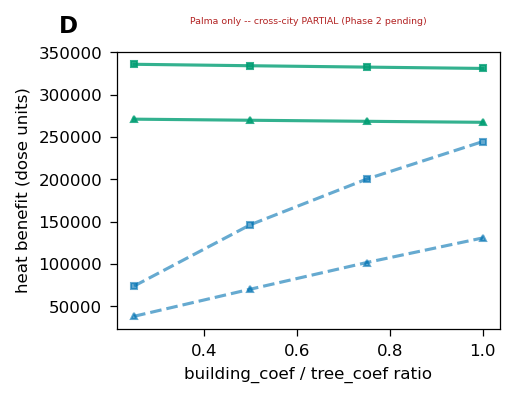

In [6]:

panel_d_ready = sensitivity_path.exists()
if panel_d_ready:
    sens = pd.read_csv(sensitivity_path)
    sens_ev = sens[sens["phenology"]=="evergreen"]
    save_source_table(sens, TAB_DIR, "panel_d")
    fig, ax = new_panel_fig(3.3, 2.4)
    dates = sens_ev["date"].unique()
    for d, marker in zip(dates, ["o","s","^","d"]):
        sub = sens_ev[sens_ev["date"]==d].sort_values("building_coef_ratio")
        if sub["tree_heat_benefit_given_buildings"].abs().sum() > 0:
            ax.plot(sub["building_coef_ratio"], sub["tree_heat_benefit_given_buildings"], f"-{marker}",
                    color="#009E73", ms=3, label=f"tree, {d}" if d==dates[0] else None, alpha=0.8)
        if sub["building_heat_benefit"].abs().sum() > 0:
            ax.plot(sub["building_coef_ratio"], sub["building_heat_benefit"], f"--{marker}",
                    color="#0072B2", ms=3, alpha=0.6)
    ax.set_xlabel("building_coef / tree_coef ratio"); ax.set_ylabel("heat benefit (dose units)")
    ax.text(0.5, 1.1, "Palma only -- cross-city PARTIAL (Phase 2 pending)", transform=ax.transAxes,
            ha="center", fontsize=4.5, color="firebrick")
    label_panel(ax, "D")
    save_panel(fig, FIG_DIR, "panel_d")
    plt.show()
else:
    fig, ax = new_panel_fig(3.3, 2.4)
    blocked_panel(ax, "D", "sensitivity table not found", [str(sensitivity_path)])
    save_panel(fig, FIG_DIR, "panel_d")
    plt.show()


## Composite

In [7]:

make_composite([FIG_DIR/"panel_a.png", FIG_DIR/"panel_b.png", FIG_DIR/"panel_c.png", FIG_DIR/"panel_d.png"], FIG_DIR, "figure4")
manifest = {"figure": "figure4_shade_and_phenology",
            "panel_a": {"status": "READY" if panel_a_ready else "BLOCKED", "note": "walk+bike combined, car BLOCKED"},
            "panel_b": {"status": "READY" if panel_b_ready else "BLOCKED", "note": "walk/bike separated, car BLOCKED"},
            "panel_c": {"status": "READY" if panel_c_ready else "BLOCKED", "note": "modelled phenology, not validated"},
            "panel_d": {"status": "PARTIAL" if panel_d_ready else "BLOCKED", "note": "Palma only, cross-city pending"}}
(TAB_DIR/"manifest.json").write_text(json.dumps(manifest, indent=2))
print(manifest)


{'figure': 'figure4_shade_and_phenology', 'panel_a': {'status': 'READY', 'note': 'walk+bike combined, car BLOCKED'}, 'panel_b': {'status': 'READY', 'note': 'walk/bike separated, car BLOCKED'}, 'panel_c': {'status': 'READY', 'note': 'modelled phenology, not validated'}, 'panel_d': {'status': 'PARTIAL', 'note': 'Palma only, cross-city pending'}}
